<a href="https://colab.research.google.com/github/Elline-Angelica/Codingbat_Answers/blob/master/6-regression-analyis/6.01-regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 6. Bivariate analysis of 2 quantitative variables

In this module, we discuss the case where *both variables are quantitative*. Specifically, we'll explore the concept of **linear regression**. Other analysis methods do exist, but those are beyond the scope of this course.

Regression analysis is an extremely flexible tool that can aid decision
making in many areas. [Kimes and Fitzsimmons (1990)](https://ecommons.cornell.edu/handle/1813/72194) describe how it has been used by La Quinta Motor Inns, a moderately priced hotel chain oriented toward serving the business traveler, to help make site location decisions.

There are two potential objectives of regression analysis.

The first objective is to *understand* how the world operates, for example, one might try to discover whether there is any gender discrimination in salaries, taking into account differences in work experience and education level.  

The second objective is to *make predictions*. A good example of this is when the variable in question is company sales, and variables such as advertising and past sales levels are used as explanatory variables.

## Learning goals

By the end of this module, you should be able to:

- Understand the definitions and terminology (indicated with 💡) used in this notebook
- Visualize data for these types of research questions with a scatter plot and regression line
- Calculate the parameters of a regression line for a given dataset (i.e. the intercept/level and slope/trend)
- Calculate Covariance $Cov$, Pearson's Product-moment Correlation Coefficient $R$, Determination Coefficient $R^2$
- Interpret the values of $Cov$, $R$ and $R^2$ using the correct terminology

In [1]:
# Package imports
import numpy as np;                                  # "Scientific computing"
import scipy.stats as stats;                         # Statistical tests

import pandas as pd;                                 # Dataframe
import matplotlib.pyplot as plt;                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic;  # Mosaic plot
import seaborn as sns;                               # Advanced dataviz

## Visualization

A good way to begin any regression analysis is to draw one or more 💡**scatterplots** (also: *X-Y plot* or graph). Each observation in the data set will be represented as a point in a Cartesian coordinate system with the value of the independent variable as the X coordinate and the value of the dependent variable as the Y coordinate.

If there is any (linear) relationship between the two variables, it is usually immediately apparent from the scatterplot.

In the examples below we will use the [Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/) dataset.

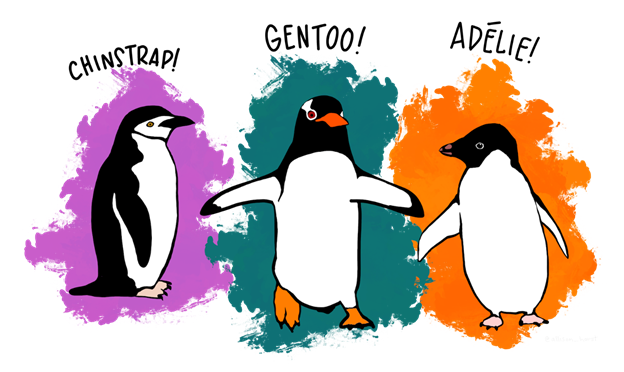

In [2]:
penguins = sns.load_dataset('penguins') # Load the Palmer Penguins demo dataset
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In Seaborn, you can use the `relplot()` function to show the relation between two qualitative variables. The independent variable should be mapped to the `x` attribute and the dependent to the `y` attribute.

In [ ]:
sns.relplot(data=penguins,  x='flipper_length_mm', y='body_mass_g')

Using other chart attributes like hue, style, etc. you can also visualize categorical variables in the data set, e.g.:

In [ ]:
sns.relplot(data=penguins,
            x='flipper_length_mm', y='body_mass_g',
            hue='species', style='sex');

Another example:

In [ ]:
sns.relplot(data=penguins,
            x='bill_depth_mm', y='bill_length_mm',
            size='body_mass_g',
            hue='species', style='sex');

## Linear regression

From the scatterplot showing the relation between `body_mass_g` and `flipper_length_mm`, it is immediately apparent that there is a systematic relationship between them. A lower flipper length corresponds with a lower body mass and a higher flipper length with a higher body mass. And although there is quite a bit of dispersion on the datapoints, the relationship seems to be linear in nature, i.e. we could approximate the relationship by drawing a line that follows the general direction of the datapoints.

### Introduction: the regression line

Scatterplots are very useful for indicating linear relationships and the
strengths of these relationships, but they do not actually *quantify* the relationships. The scatterplot does not specify *exactly* what this relationship is. For example, if the `flipper_length_mm` is 190, what would you predict `body_mass_g` to be?

To answer these questions, the relationship between the dependent variable `body_mass_g` and the independent variable `flipper_length_mm` must be quantified.

To reduce the number of points in the scatterplot and make the plots as clear as possible, we are going to take only the male, Chinstrap penguins into account.

In [ ]:
male_chinstrap = penguins[(penguins['species'] == 'Chinstrap') & (penguins['sex'] == 'Male')]
male_chinstrap.head()

Some male, Chinstrap penguins have the same `flipper_length_mm`, but a different `body_mass_g`. To simplify things, we calculate the average value for `body_mass_g` per `flipper_length_mm`.

In [ ]:
male_chinstrap = male_chinstrap.groupby('flipper_length_mm')['body_mass_g'].mean().reset_index()
male_chinstrap.head(10)

The data is plotted on this scatter plot:

In [ ]:
sns.scatterplot(data=male_chinstrap, x='flipper_length_mm', y='body_mass_g');

The scatterplot above hints at a linear relationship between these two variables. It would not be diffcult to draw a straight line through these points to produce a reasonably good fit. But which is the best line to use?

A line can be defined by $$y = ax + b$$ in which $a$ is the 💡**slope** (also: **trend**) of the line and $b$ is the 💡**intercept** (also: **level**) of the line (that's the location on the Y axis that the line crosses when X equals 0).

We will try the following values for $a$ and $b$ and see how well the line fits the data:

- a = 37 and b = -3385
- a = 23 and b = -820
- a = 23 and b = -715
- a = 20.5 and b = -92
- a = 29 and b = -1635

We need a way to 'calculate' if one line is a better fit than another line. For that we will use the sum of squared residuals.

### Squared residuals

Consider the following image. Three points in the scatterplot are shown, along with a straight line. The vertical distance from the horizontal axis to any point, can be decomposed into two parts: the vertical distance from the horizontal axis to the line, and the vertical distance from the line to the point. The first of these is called the 💡**fitted value**, and the second is called the 💡**residual**. So a fitted value is the predicted value of the dependent variable. The corresponding residual is the difference between the actual and fitted values of the dependent variable.


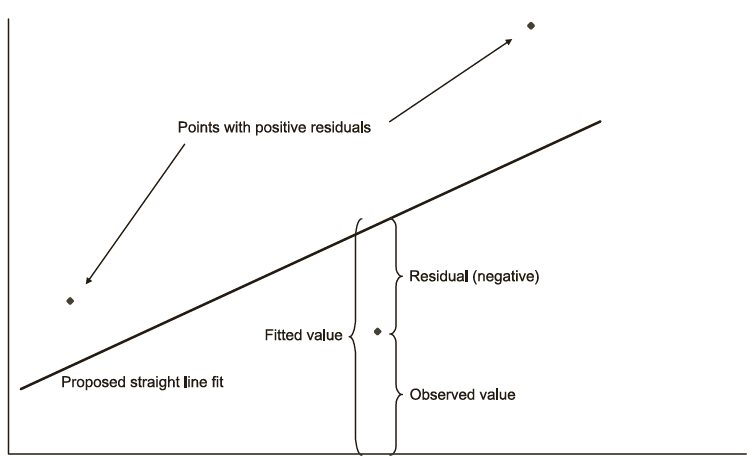


In the following code blocks, a small animation is created to try to find the straight line that fits the points the best.

The dotted green lines are the residuals.

In [ ]:
import math
import time

from matplotlib import rc
from matplotlib.animation import FuncAnimation
from matplotlib.collections import LineCollection

# set the minimum and maximum value of the x- and y-axis
xmin = math.floor(male_chinstrap['flipper_length_mm'].min() / 10) * 10
xmax = math.ceil(male_chinstrap['flipper_length_mm'].max() / 10) * 10

ymin = math.floor(male_chinstrap['body_mass_g'].min() / 10) * 10
ymax = math.ceil(male_chinstrap['body_mass_g'].max() / 10) * 10

a_values = [37, 23, 23, 20.5, 29]
b_values = [-3385, -820, -715, -92, -1635]


def animate(i):
  len_male_chinstrap_plus_2 = len(male_chinstrap) + 2

  j = i // len_male_chinstrap_plus_2
  k = i % len_male_chinstrap_plus_2

  # alles leegmaken
  axs.clear();

  # axs instellen
  axs.set_xlim((xmin, xmax));
  axs.set_ylim((ymin, ymax));

  # punten tekenen
  for l in range(len(male_chinstrap)):
    axs.plot(male_chinstrap.iloc[l, 0], male_chinstrap.iloc[l, 1], marker="o", markersize=10, markeredgecolor="red", markerfacecolor="green");


  if (k == 0):
    # these are matplotlib.patch.Patch properties
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    axs.text(0.05, 0.95, f'Attempt n° {j + 1}', transform=axs.transAxes, fontsize=14, verticalalignment='top', bbox=props);
    print()

  if k > 0:
    # rechte tekenen
    x_values = [xmin + 2, xmax - 2]
    y_values = [a_values[j] * x_values[0] +  b_values[j], a_values[j] * x_values[1] + b_values[j]]
    axs.plot(x_values, y_values, lw = 3);

  if k > 1:
    # lijn segmenten toevoegen
    segs = []
    sum_squared_residuals = 0
    for q in range(k - 1):
      sum_squared_residuals +=  ((a_values[j] * male_chinstrap.iloc[q, 0] +  b_values[j]) - male_chinstrap.iloc[q, 1]) ** 2
      segs.append([(male_chinstrap.iloc[q, 0], a_values[j]  * male_chinstrap.iloc[q, 0] +  b_values[j]),(male_chinstrap.iloc[q, 0], male_chinstrap.iloc[q, 1])]);
    lc = LineCollection(segs, linewidths=1, colors='g', linestyle='dashed')
    axs.add_collection(lc);

    # these are matplotlib.patch.Patch properties
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    # place a text box in upper left in axes coords
    axs.text(0.05, 0.95, f'Sum Squared Residuals = {sum_squared_residuals:5.2e}', transform=axs.transAxes, fontsize=14, verticalalignment='top', bbox=props);

# calculating the frames needed
len_male_chinstrap_plus_2 = len(male_chinstrap) + 2

frames = []
for i in range(len(a_values)):
  frames.append(i * len_male_chinstrap_plus_2);
  frames.append(i * len_male_chinstrap_plus_2);
  frames.append(i * len_male_chinstrap_plus_2 + 1);
  frames.append(i * len_male_chinstrap_plus_2 + 1);
  for j in range(len(male_chinstrap)):
    frames.append(i * len_male_chinstrap_plus_2 + 2 + j);
  frames.append(i * len_male_chinstrap_plus_2 + 2 + j);
  frames.append(i * len_male_chinstrap_plus_2 + 2 + j);

fig, axs = plt.subplots(figsize=(8, 8));

In [ ]:
rc('animation', html='jshtml');
anim = FuncAnimation(fig, animate, frames=frames, interval=500, repeat=False);
anim

We can measure how well a line fits the data by seeing how close it is to the data points. We'll start with the point in the lower left-hand corner of the graph. We can draw a dashed line from this point up to the gray line. The **residual** is the difference beteen the actual and fitted values of the dependent variable. The term is squared to ensure that each term is positive.
Finally we take the sum of all the squared residuals between the line and the data points. This is called the 💡**sum of squared residuals**.

*Note:* If we would simply use the sum of the residuals, the positive residuals would cancel the negative residuals. We could also minimize the sum of the _absolute values_ of the residuals and this would be a perfectly reasonable procedure. However, for technical and historical reasons, it is not the procedure usually chosen. By the way, this technique is also used in the calculation of the variance, which also contains a sum of squared deviations, but from the mean!

### Method of least squares

The *least squares line* is the line that minimizes the sum of the squared residuals.

The minimization problem itself is a calculus problem, but in essence we want to approximate a collection of points $(x_i, y_i)$ (with $i: 1, \ldots, n$) as closely as possible with a line $$\hat{y} = \beta_0 + \beta_1 x.$$ The notation $\hat{y}$ stands for 💡**an estimation for $y$**. Parameters $\beta_0$ (intercept with the Y axis or level) and $\beta_1$ (slope or trend) are calculated as follows:

$$\beta_1 = \displaystyle \frac{\sum_{i=1}^{n}(x_i - \overline{x})(y_i - \overline{y})}{\sum_{i=1}^{n}(x_i - \overline{x})^2}$$

$$\beta_0 = \overline{y} - \beta_1 \overline{x}$$

These values for $\beta_0$ and $\beta_1$ can be proven to minimize the sum of the squared residuals between the observed and the fitted values (hence the name of the "method of least squares"). However, the proof to obtain these values is beyond the scope of this course.

In the code block below, we calculate the components of the formula for $\beta_1$

In [ ]:
least_squares = pd.DataFrame({
        'x': male_chinstrap.flipper_length_mm,
        'y': male_chinstrap.body_mass_g
    })
mx = least_squares.x.mean()
my = least_squares.y.mean()

least_squares['(x-x̄)'] = least_squares['x'] - mx
least_squares['(y-ȳ)'] = least_squares['y'] - my

least_squares['(x-x̄)(y-ȳ)'] = least_squares['(x-x̄)'] * least_squares['(y-ȳ)']
least_squares['(x-x̄)²'] = least_squares['(x-x̄)'] ** 2
least_squares

In [ ]:
# Numerator and denomitator of the formula for b_0:
num = sum(least_squares['(x-x̄)(y-ȳ)'])
denom = sum(least_squares['(x-x̄)²'])
beta1 = num/denom
beta0 = my - beta1 * mx

print(f"beta_1 = {num:.4f} / {denom:.4f} = {beta1:.4f}")
print(f"beta_0 = {my:.4f} - {beta1:.4f} * {mx:.4f} = {beta0:.4f}")
print(f"ŷ = {beta0:.4f} + {beta1:.4f} x")

Let's check if the values for $\beta_0$ and $\beta_1$ provide a good approximation of the observed data:

In [ ]:
x_values = [xmin, xmax]
y_values = [beta1 * x_values[0] + beta0, beta1 * x_values[1] + beta0]

sns.lineplot(x=x_values, y=y_values);
sns.scatterplot(x=male_chinstrap.flipper_length_mm, y=male_chinstrap.body_mass_g);

This seems to be a good fit! The line is close to the data points and the residuals are small.

You can plot a data set **with its regression line** using the Seaborn functions `regplot()` or `lmplot()`:

In [ ]:
sns.lmplot(data=male_chinstrap, x='flipper_length_mm', y='body_mass_g')

The regression line corresponds with the one we drew using the calculated parameters!  

The formulas for the slope and intercept in simple linear regression given above are mostly for conceptual purposes, i.e. we don't expect you to know them by heart or to calculate them manually. Virtually all statistical software packages perform this minimization automatically.

### Calculating the parameters of a linear regression model in Python

In Python, several libraries have functions to calculate the parameters of a linear regression model.

First, there's `numpy.polyfit()`, which fits a polynomial of a specified degree to the data. For linear regression, we would specify a degree of 1.

In [ ]:
np.polyfit(male_chinstrap.flipper_length_mm, male_chinstrap.body_mass_g, deg=1)

A second way to calculate the regression line is to use the `linregress()` function from the `scipy.stats` module. This function returns the slope and intercept of the regression line, as well as other statistics such as the correlation coefficient (see below).

In [ ]:
stats.linregress(male_chinstrap.flipper_length_mm, male_chinstrap.body_mass_g)

The library **scikit-learn** also has code to calculate a linear regression model from a set of observations.

You can create an instance of the class `LinearRegression` and pass the X- and Y-values to be fitted. The array with X-values must be first converted in a 2D array.

In [ ]:
from sklearn.linear_model import LinearRegression

male_chinstrap_x = male_chinstrap.flipper_length_mm.values.reshape(-1,1)
male_chinstrap_y = male_chinstrap.body_mass_g

weight_model = LinearRegression().fit(male_chinstrap_x, male_chinstrap_y)

print(f"Regression line: ŷ = {weight_model.intercept_:.4f} + {weight_model.coef_[0]:.4f} x")

We can now predict the body_mass_g for a new penguin with flipper length 220

In [ ]:
# using the formula
body_mass_g = weight_model.intercept_ + weight_model.coef_[0] * 220
print(body_mass_g)

In [ ]:
# using the predict function of LinearRegression
body_mass_g = weight_model.predict([[220]])  # predict() needs a matrix
print(body_mass_g)


Interprete the result. Does this look ok?

This code snippet seems more complicated compared to the previous functions, but it fits in the concept of machine learning, where we have a model (the class `LinearRegression`) that can be trained on data (the X- and Y-values) to learn the parameters (the slope and intercept). The `fit()` method is used to train the model, and the `coef_` and `intercept_` attributes are used to access the learned parameters. In the chapter on time series analysis, we will write code based on a similar approach.

## Expressing the strength of a linear relationship: correlation

### Covariance

💡**Covariance** is a measure that indicates whether a (linear) relationship
between two variables is increasing or decreasing.

The **covariance of a sample** is defined as:

$$\mathrm{Cov}(X,Y) = \frac{1}{n-1}\sum_{i=1}^n(x_i - \overline{x})(y_i - \overline{y})$$

Note: The **covariance of a population** is similar, but the denominator is $n$ instead of $n-1$.

Covariance is essentially an average of products of deviations from means. If $X$ and $Y$ vary in the same direction, then when $X$ is above its mean, $Y$ will tend to be above its mean, and when $X$ is below its mean, $Y$ will tend to be below its mean. In either case, the product of deviations will be positive(a positive times a positive or a negative times a negative) so the covariance will be positive. The opposite is true when $X$ and $Y$ vary in opposite directions. Then the covariance will be negative.

Covariance measures the direction of a linear relationship between two numerical variables. If this straight line rises from left to right, the relationship is increasing and the covariance will be a positive number. If it falls from left to right, the relationship is decreasing and the covariance will be a negative number.

- $\mathrm{Cov}(X,Y) > 0$: increasing  
- $\mathrm{Cov}(X,Y) \approx 0$: no relationship  
- $\mathrm{Cov}(X,Y) < 0$: decreasing

To understand why this is the case, take a look at the plot of the chinstrap flipper length vs body mass. The dotted green lines are the means of each variable.

In [ ]:
# Plot the observations
sns.scatterplot(x=male_chinstrap.flipper_length_mm, y=male_chinstrap.body_mass_g);
# Draw the regression line through two points
sns.lineplot(x=[xmin, xmax], y=[beta1 * x_values[0] + beta0, beta1 * x_values[1] + beta0]);

# Plot the means of x and y
plt.axvline(male_chinstrap.flipper_length_mm.mean(), lw=1, color='g', linestyle='dashed')
plt.axhline(male_chinstrap.body_mass_g.mean(), lw=1, color='g', linestyle='dashed')

# Add quadrant labels
plt.text(xmin + (xmax-xmin)*.85, ymin + (ymax-ymin)*.8, "I",   backgroundcolor="bisque", fontsize="large");
plt.text(xmin + (xmax-xmin)*.15, ymin + (ymax-ymin)*.2, "II",  backgroundcolor="bisque", fontsize="large");
plt.text(xmin + (xmax-xmin)*.15, ymin + (ymax-ymin)*.8, "III", backgroundcolor="bisque", fontsize="large");
plt.text(xmin + (xmax-xmin)*.85, ymin + (ymax-ymin)*.2, "IV",  backgroundcolor="bisque", fontsize="large");

Each observation will contribute to the sum that results in the value of the covariance:

- In quadrant I, both x and y are *larger* than their respective means, so $(x - \overline{x})$ and $(y - \overline{y})$ are both *positive*, resulting in a **positive** term
- In quadrant II, both x and y are *smaller* than their respective means, so $(x - \overline{x})$ and $(y - \overline{y})$ are both *negative*, resulting in a **positive** term
- In quadrant III, however, $(x - \overline{x})$ is *negative* while $(y - \overline{y})$ is *positive*, resulting in a **negative** term
- In quadrant IV,  $(x - \overline{x})$ is *positive* while $(y - \overline{y})$ is *negative*, also resulting in a **negative** term

So, all observations in quadrants I and II will make the covariance larger, and observations in quadrants III and IV will make it smaller. If there are a lot of observations in I and II, and fewer in III and IV (which is the case in datasets with an increasing relation), the overall result will be a positive covariance. A lot of observations in III and IV and fewer in I and II (i.e. a decreasing relation) will result in a negative covariance.

If we calculate the covariance for this dataset, we expect a positive result:

In [ ]:
# Calculate covar using the formula
covar = sum((male_chinstrap.flipper_length_mm - male_chinstrap.flipper_length_mm.mean()) *
            (male_chinstrap.body_mass_g - male_chinstrap.body_mass_g.mean())) / (len(male_chinstrap) - 1)

print(f"Cov(x,y) = {covar}")

To calculate covariance, you can use the Numpy function `cov`. It's a bit complicated to use, because it returns not a single value, but a covariance matrix:

```
[[cov(a,a), cov(a,b)],
 [cov(b,a)  cov(b,b)]]
```

Remark that the definition of `cov(a,a)` reduces to the variance of `a`! Can you explain why?

We can extract the value we need with:

In [ ]:
np.cov(
    male_chinstrap.flipper_length_mm,
    male_chinstrap.body_mass_g,
    ddof=1)[0][1]

Remark that we use the parameter `ddof=1` (delta Degrees of Freedom) for the *sample* covariance, which produces an unbiased estimate!

Covariance has a serious limitation as a descriptive measure because it is very sensitive to the units in which X and Y are measured. For example, if we had expressed the body mass of the chinstrap penuins in kg instead of g, the covariance would be $\approx$ 1.836 instead of $\approx$ 1836. This limits the usefulness of covariance as a descriptive measure in itself.

### Pearson's product-moment correlation coefficient

The 💡**correlation coefficient** (or, specifically, *[Pearson's product-moment correlation coefficient](https://en.wikipedia.org/wiki/Pearson_correlation_coefficient)*) is defined as:

$$R = \frac{\mathrm{Cov}(X,Y)}{\sigma_x \sigma_y} = \frac{\sum(x_i - \overline{x})(y_i - \overline{y})}{\sqrt{\sum{(x_i-\overline{x})^2}} \sqrt{\sum{(y_i - \overline{y})^2}}}$$

$R$ is a measure for the strength of a linear correlation between 𝑥 and 𝑦.

Correlation is a _unitless_ quantity that is unaffected by the measurement scale. For example, the correlation is the same regardless of whether the variable _X_ (e.g. height of a person) is measured in millimeters, centimeters, decimeters or meters.

The correlation is not only unaffected by the units of measurement of the two variables, but it is always between −1 and +1. The closer it is to either of these two extremes, the closer the points in a scatterplot are to a straight line, either in the negative or positive direction.

On the other hand, if the correlation is close to 0, the scatterplot is typically a 'cloud' of points with no apparent relationship. However, although it is not common, it is also _possible_ that the points are close to a curve and have a correlation close to 0. This is because correlation is relevant only for measuring **linear** relationships.

In [ ]:
# Correlation calculated from covariance
stdx = male_chinstrap.flipper_length_mm.std()
stdy = male_chinstrap.body_mass_g.std()

R1 = covar / (stdx * stdy)
print(f"R ≈ {covar:.4f} / ( {stdx:.4f} * {stdy:.4f} ) ≈ {R1:.4f}")

In [ ]:
# Correlation from elaborated formula
xx = male_chinstrap.flipper_length_mm - male_chinstrap.flipper_length_mm.mean()
yy = male_chinstrap.body_mass_g - male_chinstrap.body_mass_g.mean()
R2 = sum(xx * yy) / (np.sqrt(sum(xx ** 2) * sum(yy ** 2)))
print(f"R ≈ {R2:.4f}")

In [ ]:
np.corrcoef(
    male_chinstrap.flipper_length_mm,
    male_chinstrap.body_mass_g)

In [ ]:
# Python function numpy.corrcoef() - returns a matrix, like numpy.cov()
cor = np.corrcoef(
    male_chinstrap.flipper_length_mm,
    male_chinstrap.body_mass_g)[0][1]
print(f"R ≈ {cor:.4f}")

The value of $R$ indicates an increasing and strong linear relation between `flipper_length_mm` and `body_mass_g`.

**Remark:** It is incorrect to say that a correlation coefficient of .82 indicates a "strong increasing relationship". The correlation coefficient says nothing about the steepness of the relation ship, but only how closely the points are located near a straight line. A correlation coefficient of .82 indicates a strong linear relationship, but it could be a very steep or a very flat line.

### Coefficient of determination

The 💡**coefficient of determination** $R^2$ gives the percentage of the variance of the observed values relative to the regression line, i.e. the interpretation of $R^2$ is 'the fraction of variation of the dependent variable explained by the regression line'. The closer to 1, the more the variance is explained by the regression line, and the stronger the linear relation between the variables: when the residuals are small, $R^2$ will be close to 1, but when they are large, $R^2$ will be close to 0. Graphically, the higher the coefficient of determination, the closer the observations are located near the regression line.

The determination coefficient can be calculated as the square of Pearson's correlation coefficient:

In [ ]:
cor ** 2

So for this case, about 68% of the variance in the observations is explained by the regression line, which indicates a strong linear relation (see below).

The `LinearModel` class also has a method to calculate the coefficient of determination. We first need to call the `fit()` method and then we can use the method `score()` that returns $R^2$

In [ ]:
chinstrap_x = male_chinstrap.flipper_length_mm.values.reshape(-1,1)
chinstrap_y = male_chinstrap.body_mass_g

families_model = LinearRegression().fit(chinstrap_x, chinstrap_y)
families_model.score(chinstrap_x, chinstrap_y)

### Interpretation of R and R²

Depending on the value of $|R|$ (or $R^2$), you can draw a conclusion about the strength of the linear relation between the two variables:

| $abs(R)$  |  $R^2$   | Explained variance |   Linear relation    |
| :-------: | :------: | :----------------: | :------------------: |
|   < .3    |   < .1   |       < 10%        |      very weak       |
|  .3 - .5  | .1 - .25 |     10% - 25%      |         weak         |
|  .5 - .7  | .25 - .5 |     25% - 50%      |       moderate       |
| .7 - .85  | .5 - .75 |     50% - 75%      |        strong        |
| .85 - .95 | .75 - .9 |     75% - 90%      |     very strong      |
|   > .95   |   > .9   |       > 90%        | exceptionally strong |

**Remark** that the value of $R$ doesn't say anything about the steepness of the regression line! It only indicates how close the observations are to the regression line. Therefore, it is **wrong** to say that a value of e.g. $R = 0.8$ indicates a strongly increasing linear relation! Instead, you should say it indicates an _increasing and strong linear relation_.

The image below with the correlation coefficient for several data sets illustrates this.


<img src="https://upload.wikimedia.org/wikipedia/commons/d/d4/Correlation_examples2.svg" width="800"/>

### Considerations

- The correlation coefficient only looks at the relationship between *two* variables. Interactions with other variables are not taken into account.
- The correlation coefficient explicitly does **not** assume or prove a **causal** relationship!
- Pearson's correlation coefficient only measures the strength of a **linear** relationship. It is possible that two variables have a strong non-linear relationship, but a correlation close to 0.
- $R^2$ is easier to interpret than $R$. The interpretation of $R^2$ as the square of a correlation helps to clarify the issue of when a correlation is "large".  
    - For example: how much better is R = 0.8 than R = 0.7 or R = 0.9?
    - If the correlation between two variables Y and X is ±0.8, the regression of Y on X will have an $R^2$ of 0.64; that is, the regression with X as the
only explanatory variable will explain 64% of the variation in Y.
    - If the correlation drops to ±0.7, this percentage drops to 49%;
    - If the correlation increases to ±0.9, the percentage increases to 81%.
- The point is that before a single variable X can explain a large percentage of the variation in some other variable Y, the two variables must be highly correlated, in either a positive or negative direction.

Another example: How much better is R = 0.7 than R = 0.5?  

- R² = 0.7 * 0.7 ~ 0.5 => 50% of the original variation in explained  
- R² = 0.5 * 0.5 = 0.25 => 25% of the original variation in explained  

With R², it is easy to see that the first correlation is twice as good as the second.